## Initialize the PepFoundry Interface

**Description:**  
This section shows how to import and initialize the `PepFoundry` class, which is the main interface for handling peptide-to-SMILES conversions.  

**Arguments:**  
- `custom_dict_path` (*str, optional*): Path to a custom amino acid dictionary (Excel file).  
  - If not provided, the class automatically loads the **default amino acid dictionary**.  

**Steps:**  
1. Import the `PepFoundry` class from the `pepfoundry.interface` module.  
2. Create an instance of the `PepFoundry` class, optionally providing a custom dictionary path.  

**Expected Output:**  
- An initialized `PepFoundry` object, ready for use in subsequent peptide processing tasks.  

---


In [6]:
from pepfoundry.interface import PepFoundry

pepfoundry = PepFoundry() 
#pepfoundry = PepFoundry(custom_dict_path="pepfoundry/project/core/modified_amino_acids_library.xlsx") 

## Generate Peptide Molecules from Peptide Strings  
<div style="text-align: center;">
    <img src="fig/PepFoundry.gif" alt="">
</div>


**Description:**  
This example demonstrates how to generate **peptide** molecules from peptide notation strings using the `PepFoundry` interface. The method converts the peptide string into an RDKit molecular object, forms a cycle if specified, and optionally visualizes the resulting peptide structure.  

**Steps:**  
1. Define a list of peptide strings with specific notations (e.g., `{PEG2}pr{GlcNAc-T}l{am}`).  
2. Use the `get_peptide` method with the argument. 
3. The method returns an **RDKit molecule object** representing the peptide.    

**Arguments:**  
- `sequence`: Peptide notation string.  
- `plot_peptide`: Boolean flag; if `True`, displays the 2D structure of the peptide.(default `False`). 
- `peptide_type`: String, `"linear"` for cyclic peptides. (default `"linear"`)  

**Outputs:**  
- **RDKit molecule object**: The molecular graph corresponding to the peptide.  
- **2D visualization**: If `plot_peptide=True`, the peptide structure is displayed inline.  



---------------------------------------------------
Peptide: {pra}w{Pra}nT{am}


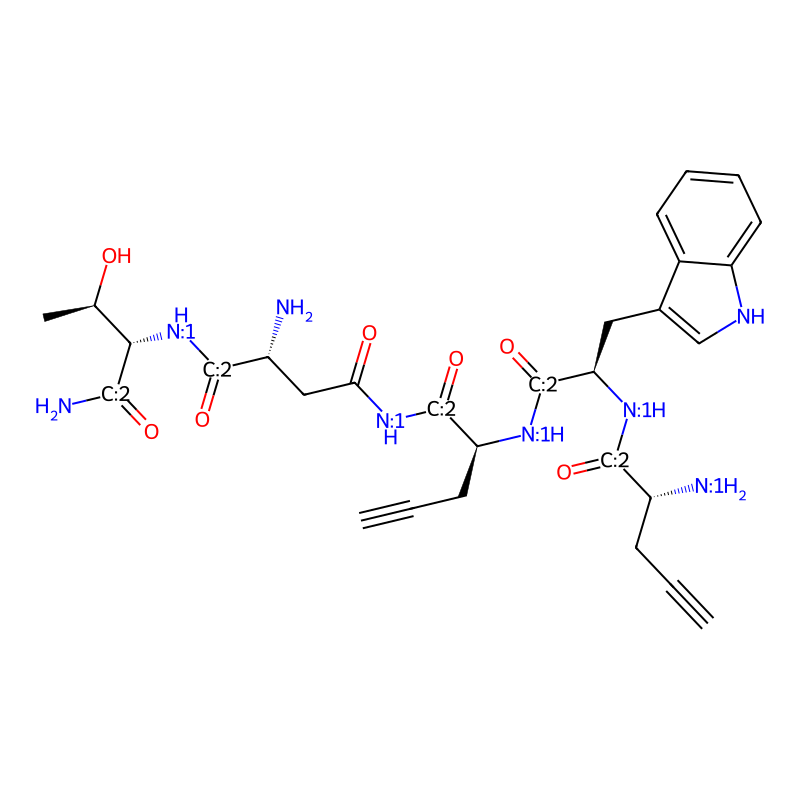

---------------------------------------------------
Peptide: r{k-(4-Bba)}vrctci{pra}{am}


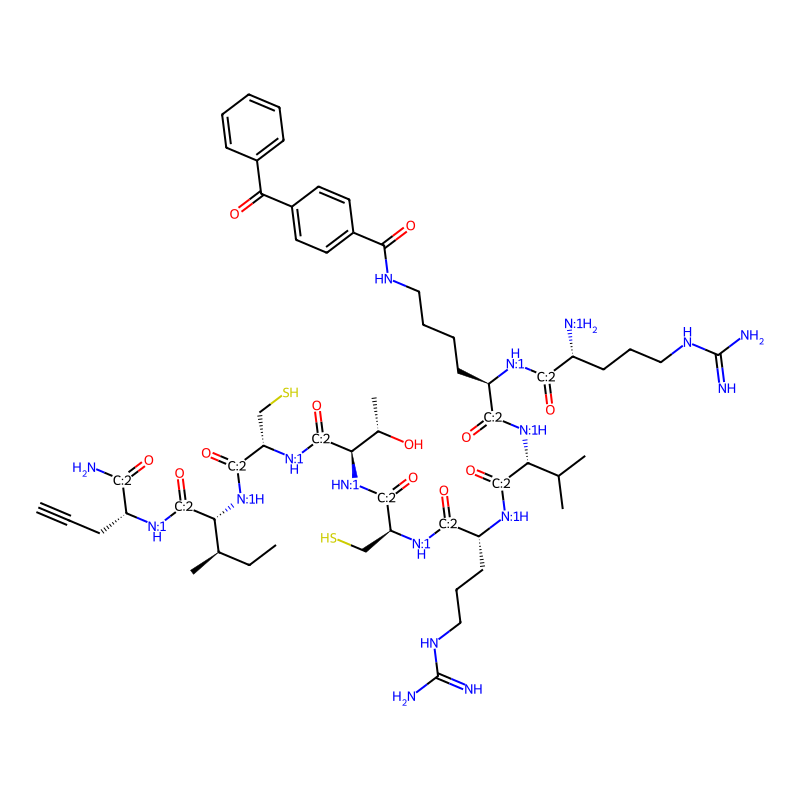

---------------------------------------------------
Peptide: {PEG2}prl{am}


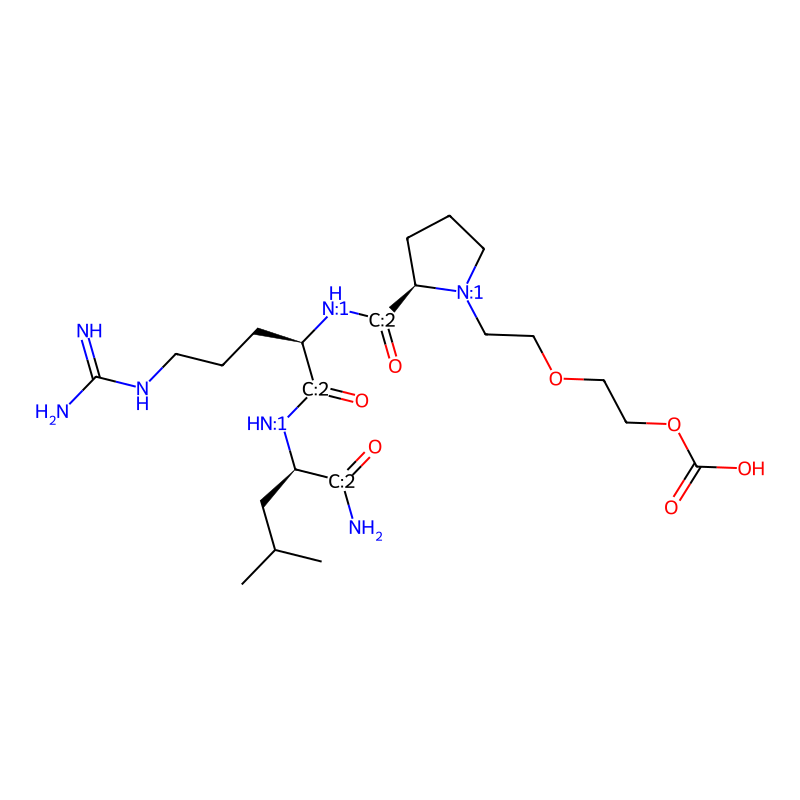

---------------------------------------------------
Peptide: {PEG2}pr{GlcNAc-T}l{am}


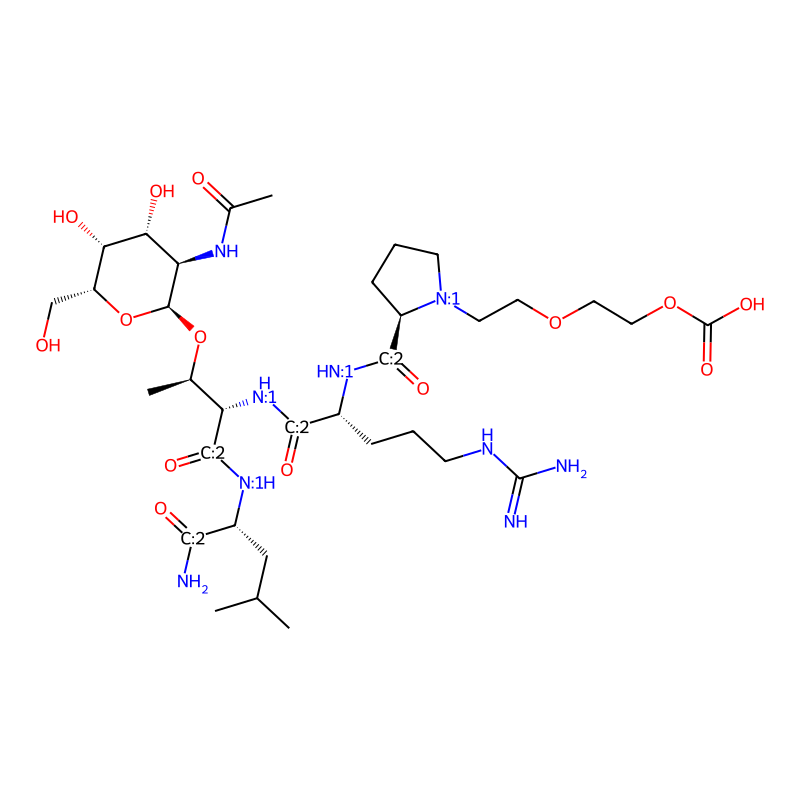

In [2]:
peptides = [
            "{pra}w{Pra}nT{am}",
            "r{k-(4-Bba)}vrctci{pra}{am}",
            "{PEG2}prl{am}",
            "{PEG2}pr{GlcNAc-T}l{am}",
            ]

for pep in peptides:
    print('---------------------------------------------------')
    print('Peptide:', pep)
    mol = pepfoundry.get_peptide(pep, plot_peptide=True) #<--- This is the RdKit molecule object for the peptide"
    

## Generate Cyclic Peptide Molecules from Peptide Strings  
<div style="text-align: center;">
    <img src="fig/cycle.gif" alt="">
</div>

**Description:**  
This example demonstrates how to generate **cyclic peptide** molecules from peptide notation strings using the `PepFoundry` interface. The method converts the peptide string into an RDKit molecular object, forms a cycle if specified, and optionally visualizes the resulting peptide structure.  

**Steps:**  
1. Define a list of cyclic peptide strings with specific notations (e.g., `r{k-(4-Bba)}vrctci{pra}`).  
2. Use the `get_peptide` method with the argument `peptide_type="cycle"` to generate a cyclic peptide.  
3. The method returns an **RDKit molecule object** representing the cyclic peptide.    

**Arguments:**  
- `sequence`: Peptide notation string.  
- `plot_peptide`: Boolean flag; if `True`, displays the 2D structure of the peptide.(default `False`). 
- `peptide_type`: String, `"cycle"` for cyclic peptides. (default `"linear"`)  

**Outputs:**  
- **RDKit molecule object**: The molecular graph corresponding to the cyclic peptide.  
- **2D visualization**: If `plot_peptide=True`, the cyclic peptide structure is displayed inline.  



---------------------------------------------------
Peptide: {pra}w{Pra}nT


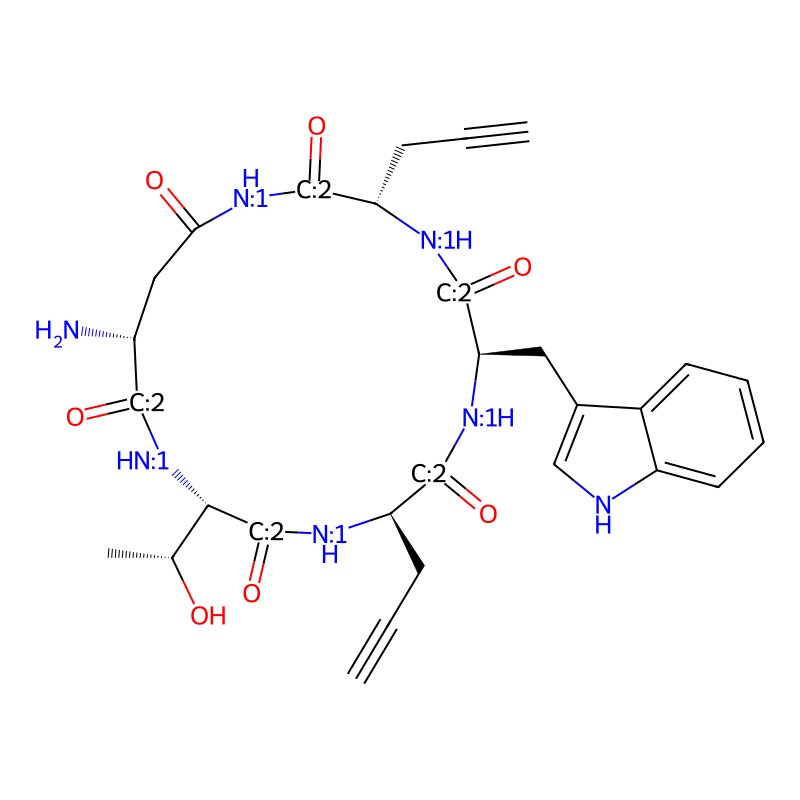

---------------------------------------------------
Peptide: r{k-(4-Bba)}vrctci{pra}


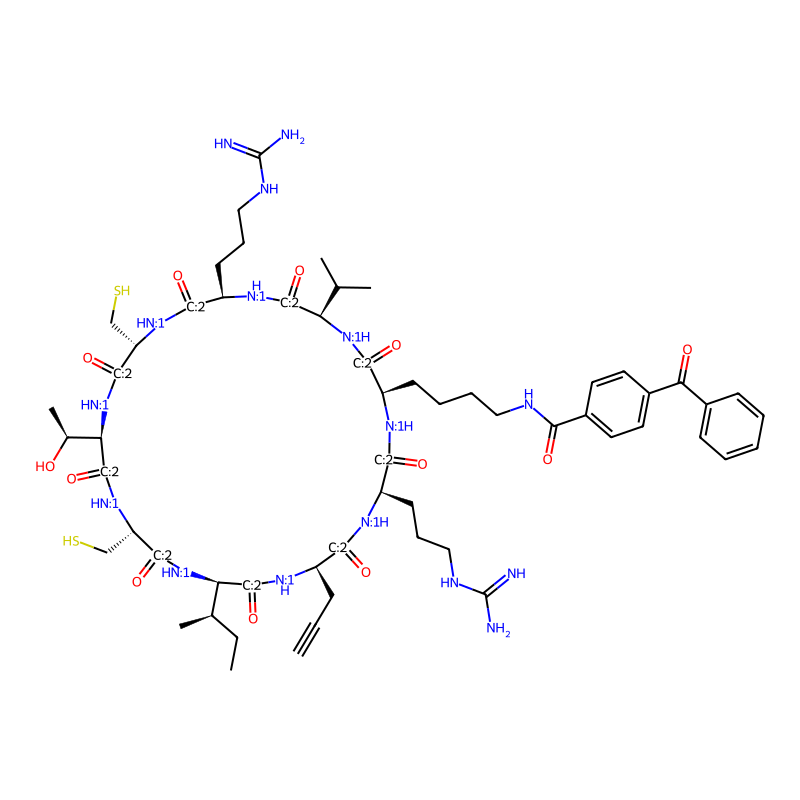

---------------------------------------------------
Peptide: prlWmk


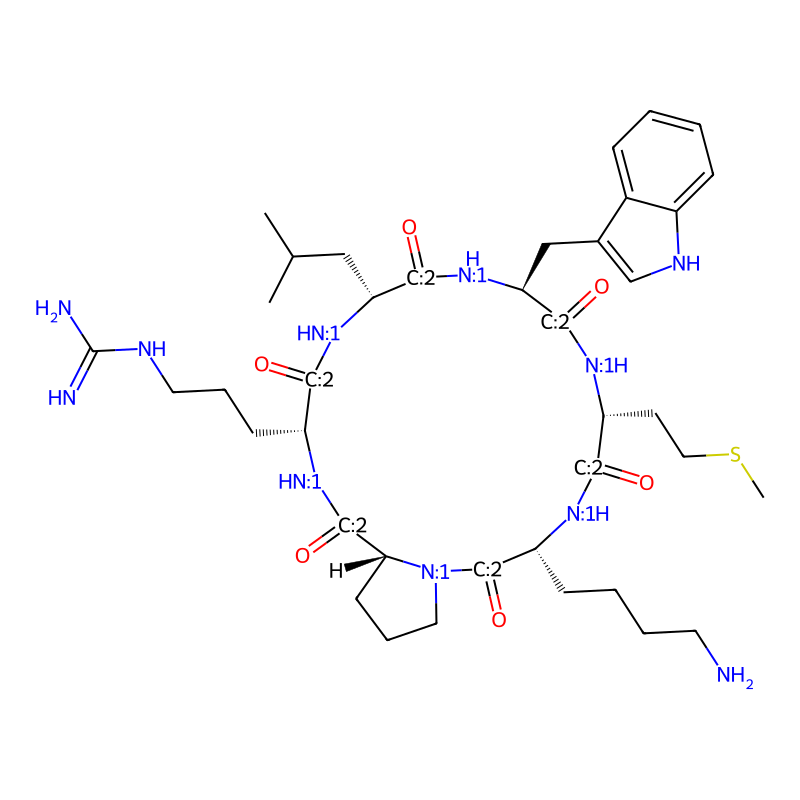

---------------------------------------------------
Peptide: pr{GlcNAc-T}l{h-r}


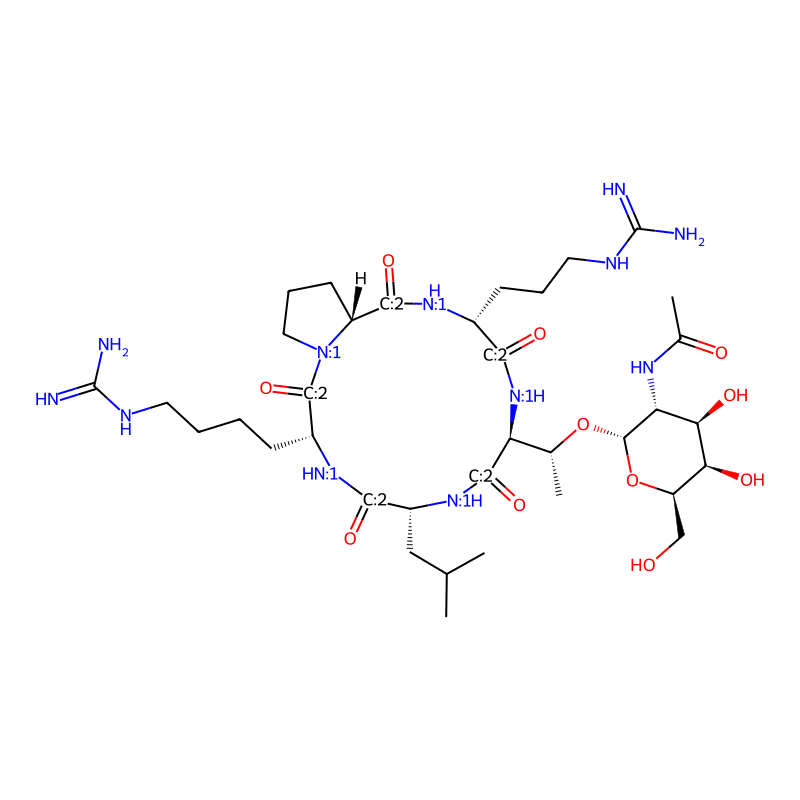

In [3]:
peptides = [
            "{pra}w{Pra}nT",
            "r{k-(4-Bba)}vrctci{pra}",
            "prlWmk",
            "pr{GlcNAc-T}l{h-r}",
            ]

for pep in peptides:
    print('---------------------------------------------------')
    print('Peptide:', pep)
    mol = pepfoundry.get_peptide(pep, plot_peptide=True, peptide_type='cycle') 

## Generate Peptides and Highlight Peptide Bonds

**Description:**  
This example demonstrates how to generate peptide molecules from notation strings using the `PepFoundry` interface and highlight the **peptide bonds** in the molecular structures, emphasizing the connections between amino acids.

**Steps:**  
1. Define a list of peptide notation strings, including modifications and terminal groups.  
2. Iterate through each peptide string and use `get_peptide` to generate the corresponding RDKit molecule object.  
3. Visualize the molecule and highlight the peptide bonds using `get_plot_aminoacids`.  

**Arguments for `get_peptide`:**  
- `sequence (str)`: Peptide string notation.  
- `plot_peptide (bool)`: Whether to display the peptide molecule (optional).  

**Arguments for `get_plot_aminoacids`:**  
- `mol (Chem.Mol)`: RDKit molecule object of the peptide.  
- `highlight_bonds (bool)`: If `True`, peptide bonds are highlighted.  
- `obtain_amino_acids (bool)`: If `False`, skips returning amino acid objects.  

**Expected Output:**  
- Visual representation of each peptide molecule with peptide bonds clearly highlighted.  
- Console output displaying the original peptide strings.  



Peptide: {PEG4[CH2CH2]}rtvrctci{am}


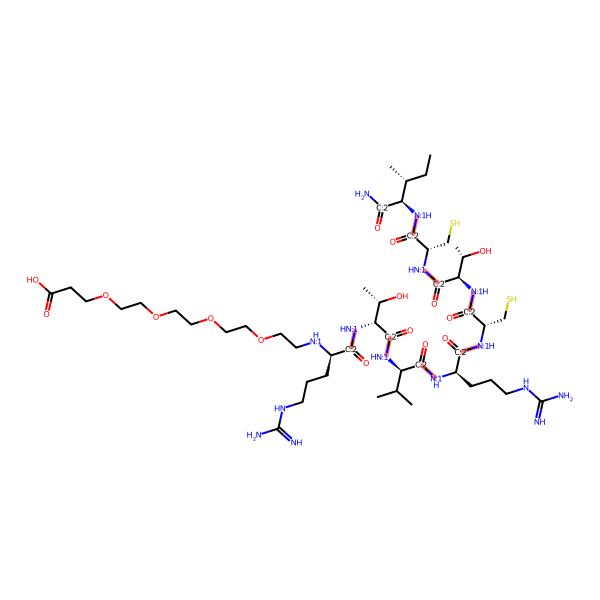

Peptide: {pra}w{Pra}nT{am}


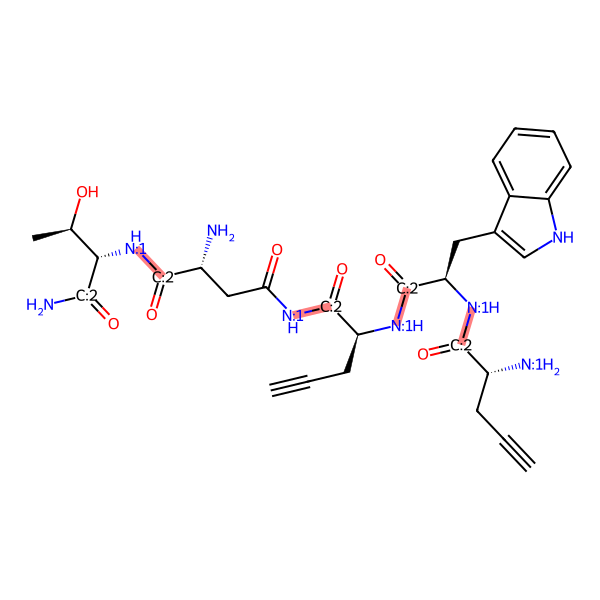

Peptide: {PEG2}prl{am}


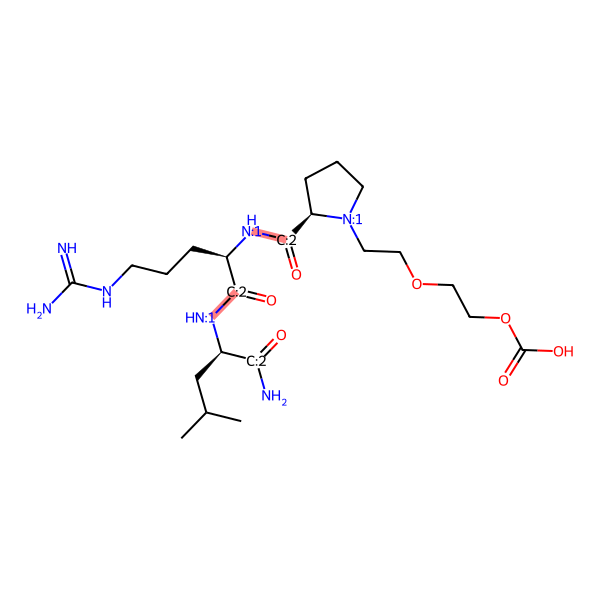

Peptide: r{k-(4-Bba)}vrctci{pra}{am}


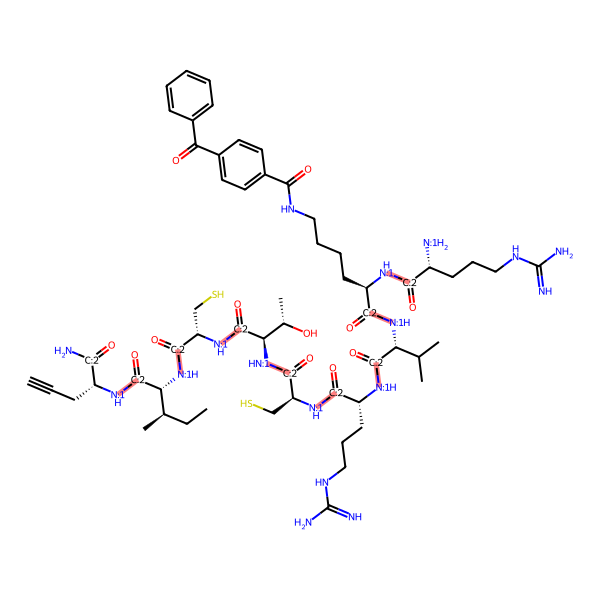

Peptide: {PEG2}pr{GlcNAc-T}l{am}


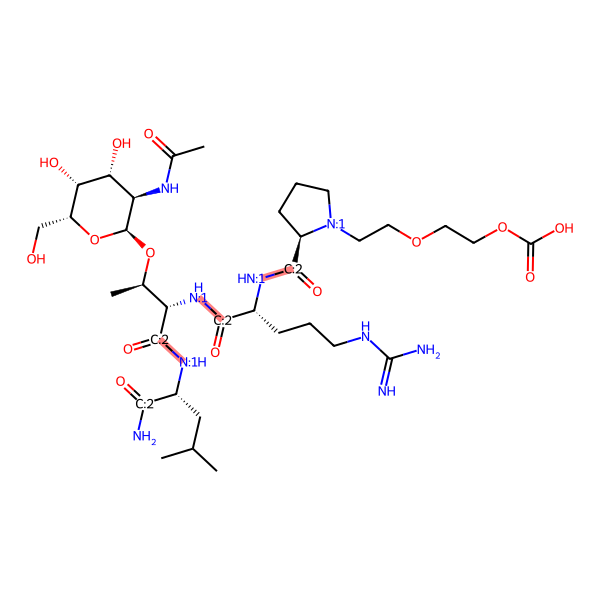

In [4]:
peptides = [
            "{PEG4[CH2CH2]}rtvrctci{am}",
            "{pra}w{Pra}nT{am}",
            "{PEG2}prl{am}",
            "r{k-(4-Bba)}vrctci{pra}{am}",
            "{PEG2}pr{GlcNAc-T}l{am}",
            ]

for pep in peptides:
    print('Peptide:', pep)
    mol = pepfoundry.get_peptide(pep, plot_peptide=False) 
    pepfoundry.get_plot_aminoacids(mol, highlight_bonds=True, obtain_amino_acids=False)

## Generate Cyclic Peptides and Highlight Peptide Bonds

---------------------------------------------------
Peptide: {pra}w{Pra}nT


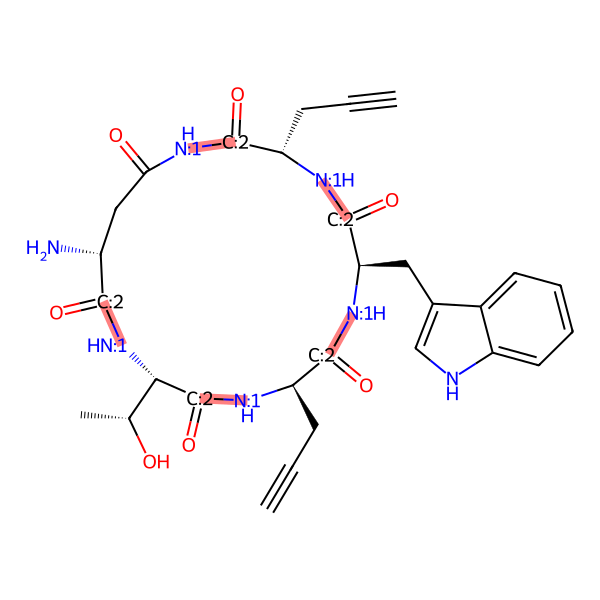

---------------------------------------------------
Peptide: r{k-(4-Bba)}vrctci{pra}


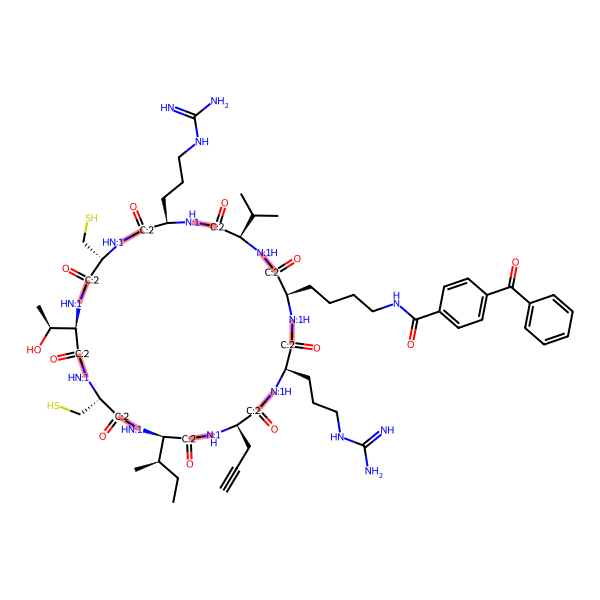

---------------------------------------------------
Peptide: prlWmk


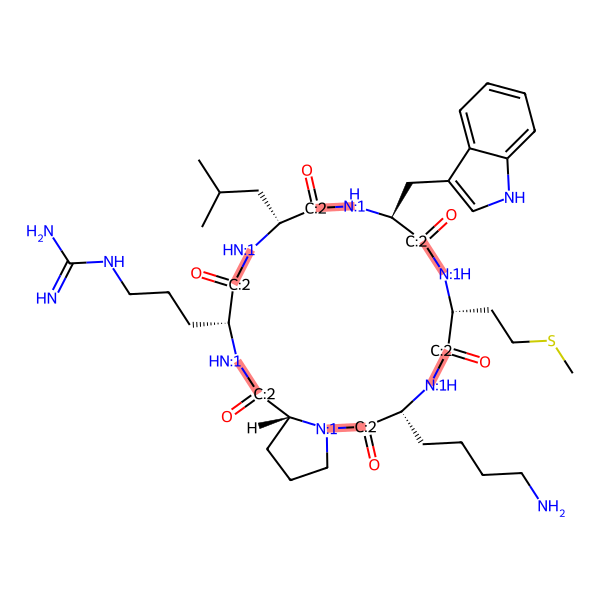

---------------------------------------------------
Peptide: pr{GlcNAc-T}l{h-r}


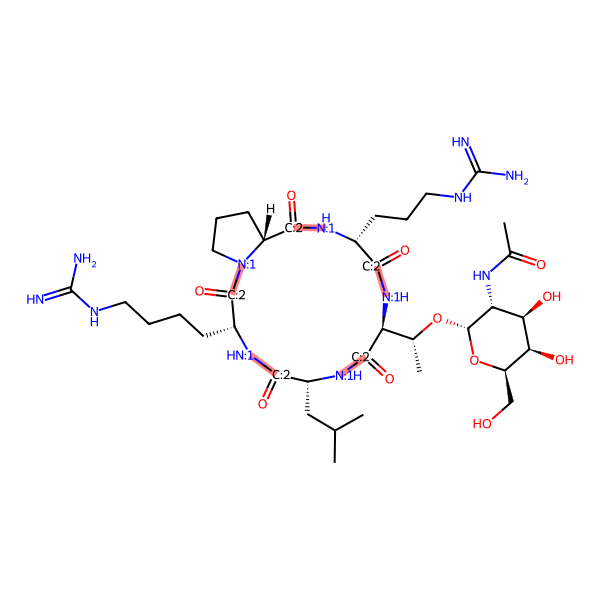

In [5]:
peptides = [
            "{pra}w{Pra}nT",
            "r{k-(4-Bba)}vrctci{pra}",
            "prlWmk",
            "pr{GlcNAc-T}l{h-r}",
            ]

for pep in peptides:
    print('---------------------------------------------------')
    print('Peptide:', pep)
    mol = pepfoundry.get_peptide(pep, plot_peptide=False, peptide_type='cycle') 
    pepfoundry.get_plot_aminoacids(mol, highlight_bonds=True, obtain_amino_acids=False)

## Fragment Peptides into Individual Amino Acids

**Description:**  
This example shows how to fragment peptide molecules into their constituent amino acids.  
Each amino acid is extracted and visualized separately, without highlighting the peptide bonds.

**Steps:**  
1. Define a list of peptide notation strings, including modifications and terminal groups.  
2. For each peptide string, generate the corresponding RDKit molecule object (without plotting the full peptide).  
3. Use `get_plot_aminoacids` with `obtain_amino_acids=True` to fragment and display the individual amino acids.  
4. Print the original peptide string for reference.  

**Arguments for `get_plot_aminoacids`:**  
- `mol (Chem.Mol)`: RDKit molecule object of the peptide.  
- `highlight_bonds (bool)`: If `False`, peptide bonds are not highlighted.  
- `obtain_amino_acids (bool)`: If `True`, the peptide is fragmented into its amino acid components.  

**Expected Output:**  
- Separate visualizations of each amino acid fragment derived from the peptide.  
- Console output showing the corresponding peptide notation strings.  

---


Peptide: {PEG4[CH2CH2]}rtvrctci{am}


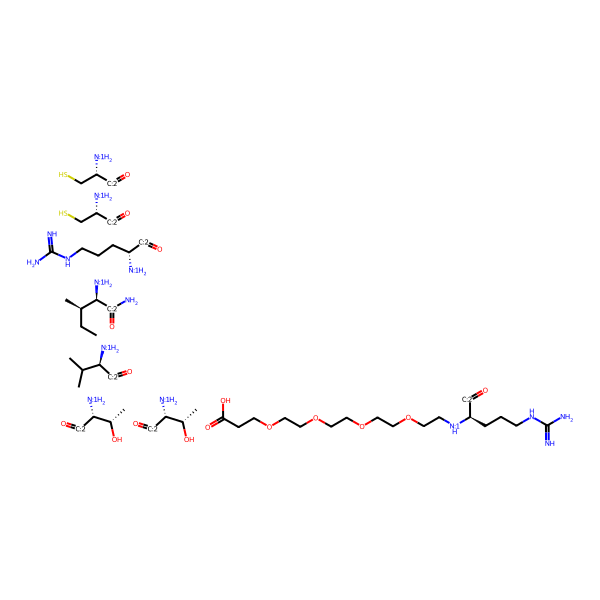

Peptide: {pra}w{Pra}nT{am}


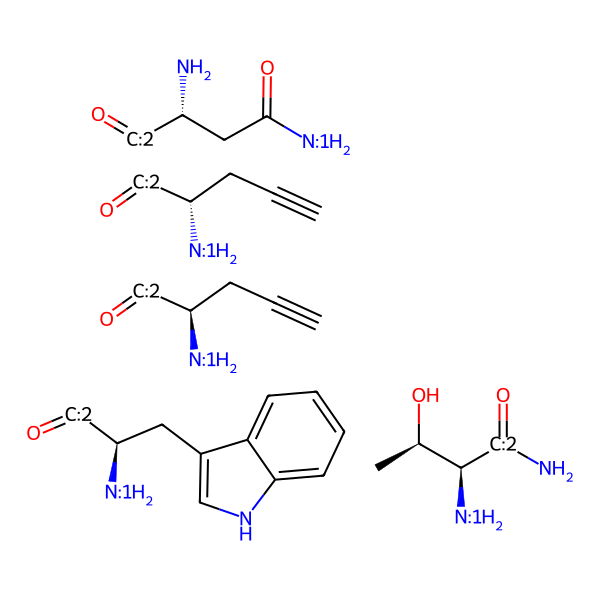

Peptide: {PEG2}prl{am}


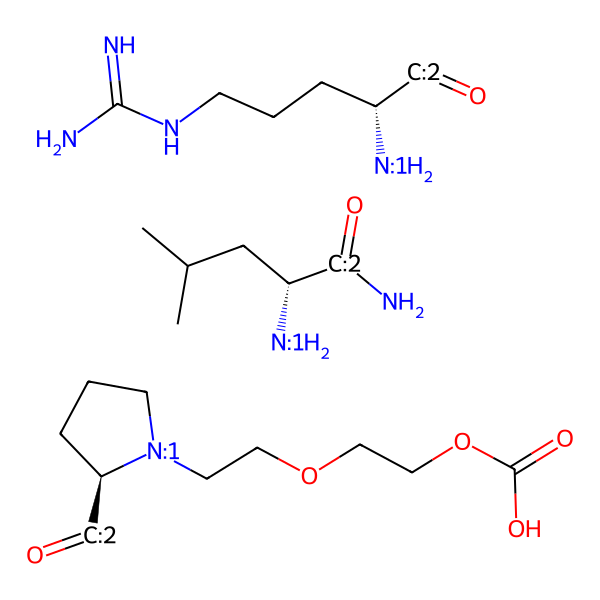

Peptide: r{k-(4-Bba)}vrctci{pra}{am}


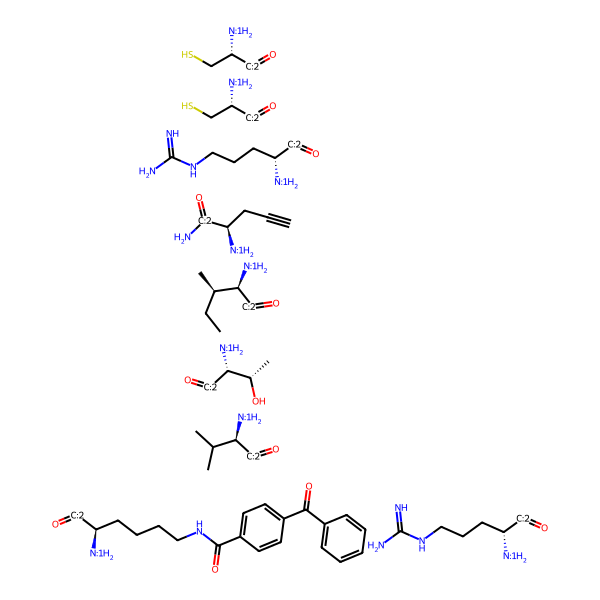

Peptide: {PEG2}pr{GlcNAc-T}l{am}


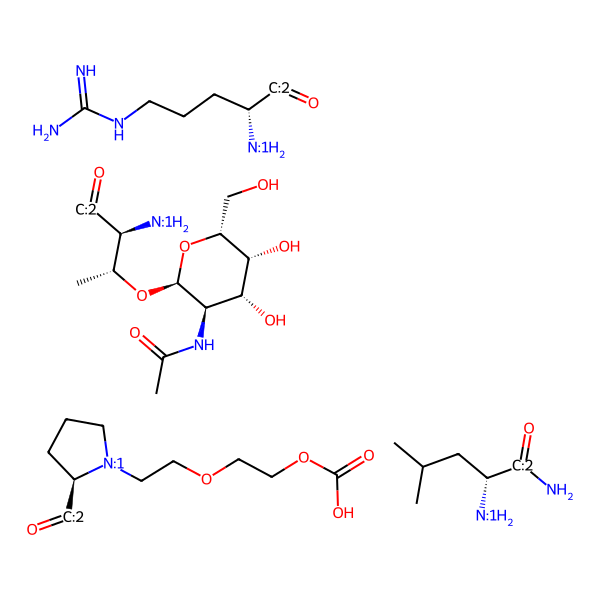

In [6]:
peptides = [
            "{PEG4[CH2CH2]}rtvrctci{am}",
            "{pra}w{Pra}nT{am}",
            "{PEG2}prl{am}",
            "r{k-(4-Bba)}vrctci{pra}{am}",
            "{PEG2}pr{GlcNAc-T}l{am}",
            ]

for pep in peptides:
    print('Peptide:', pep)
    mol = pepfoundry.get_peptide(pep, plot_peptide=False) 
    pepfoundry.get_plot_aminoacids(mol, highlight_bonds=False, obtain_amino_acids=True)

## Fragment Cyclic Peptides into Individual Amino Acids

---------------------------------------------------
Peptide: {pra}w{Pra}nT


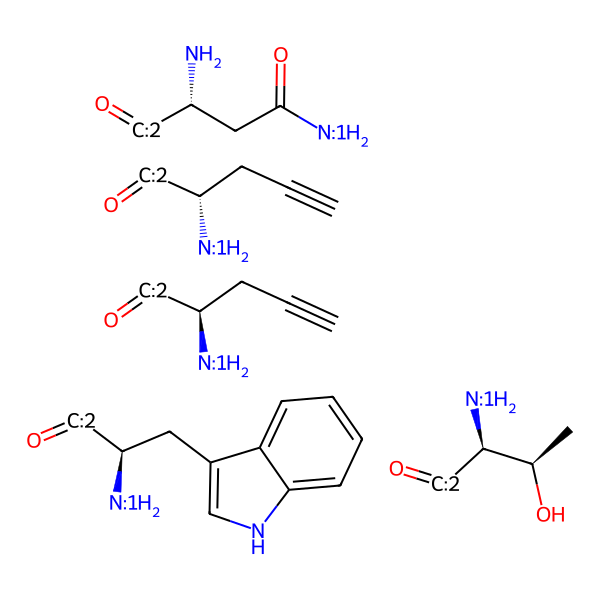

---------------------------------------------------
Peptide: r{k-(4-Bba)}vrctci{pra}


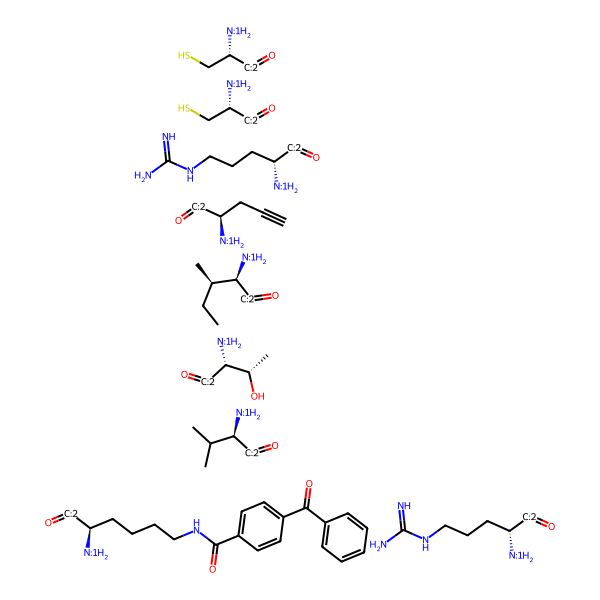

---------------------------------------------------
Peptide: prlWmk


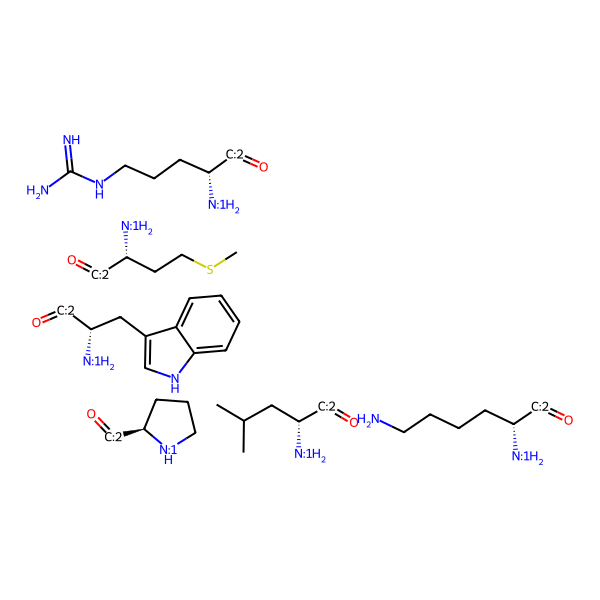

---------------------------------------------------
Peptide: pr{GlcNAc-T}l{h-r}


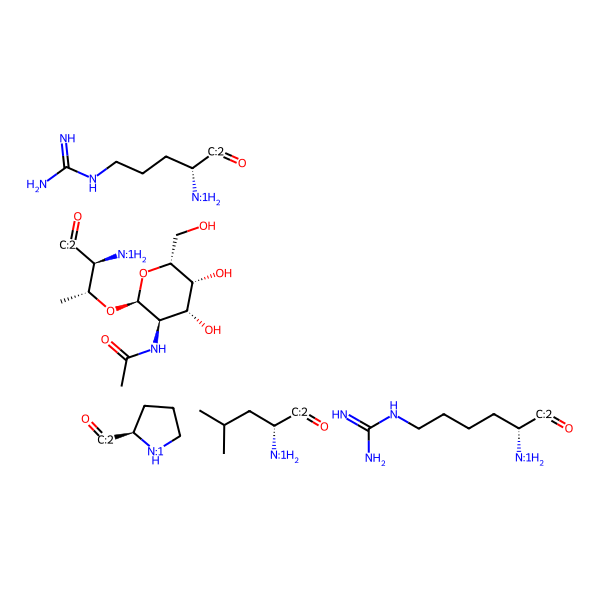

In [7]:
peptides = [
            "{pra}w{Pra}nT",
            "r{k-(4-Bba)}vrctci{pra}",
            "prlWmk",
            "pr{GlcNAc-T}l{h-r}",
            ]

for pep in peptides:
    print('---------------------------------------------------')
    print('Peptide:', pep)
    mol = pepfoundry.get_peptide(pep, plot_peptide=False, peptide_type='cycle') 
    pepfoundry.get_plot_aminoacids(mol, highlight_bonds=False, obtain_amino_acids=True)

## Extract Atomic-Level Features from Peptides

**Description:**  
This example demonstrates how to extract atomic-level features from peptide molecules.  
The features are represented as tensors for atoms (nodes) and bonds (edges), which can be used for machine learning or graph-based modeling.

**Steps:**  
1. Print the description of the available atomic feature library using `get_description_library_atomic_features`.  
2. Define a list of peptide notation strings, including modifications and terminal groups.  
3. For each peptide string:  
   - Generate the corresponding RDKit molecule object (without plotting).  
   - Extract node (atom) and edge (bond) feature tensors with `get_peptide_tensor_atomic_features`.  
   - Print the shapes and values of the extracted tensors.  

**Arguments for `get_description_library_atomic_features` and `get_peptide_tensor_atomic_features`:**  
- `mol (Chem.Mol)`: RDKit molecule object of the peptide.  
- `chiralities (bool, optional)`: 
    - If True, the printed feature vectors include chirality information for each atom. 
    - If False (default), chirality is not included in the feature vectors.
- `device (str)`: Computational device (`"cpu"` (default) or `"cuda"`).  

**Note:**  
- Node feature tensors → rows correspond to atoms, columns correspond to atomic feature values.  
- Edge feature tensors → rows correspond to bonds, columns correspond to bond feature values.  

**Expected Output:**  
- Printed description of the atomic feature library.  
- For each peptide:  
  - Node features tensor shape and values.  
  - Edge features tensor shape and values.  

---

### Atomic Feature Extraction *without* Chirality

In [8]:
peptides = [
            "{PEG4[CH2CH2]}rtvrctci{am}",
            "{pra}w{Pra}nT{am}",
            "{PEG2}prl{am}",
            "r{k-(4-Bba)}vrctci{pra}{am}",
            "{PEG2}pr{GlcNAc-T}l{am}",
            ]

# 1. Print the description of the atomic feature library
pepfoundry.get_description_library_atomic_features()

# 2. Process each peptide and extract features
for pep in peptides:
    print('-------------------------------------------------')
    print('\nPeptide:', pep)
    mol = pepfoundry.get_peptide(pep, plot_peptide=False)  # RDKit molecule object
    nodes_features, edges_features = pepfoundry.get_peptide_tensor_atomic_features(mol, device="cpu")

    print('Nodes features Shape:', nodes_features.shape)
    print('Edges features Shape:', edges_features.shape)
    print('Nodes features:', nodes_features)
    print('Edges features:', edges_features)
    


Node feature vector length: 24
Edge feature vector length: 16
-------------------------------------------------

Peptide: {PEG4[CH2CH2]}rtvrctci{am}
Nodes features Shape: torch.Size([81, 24])
Edges features Shape: torch.Size([80, 16])
Nodes features: tensor([[0., 1., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 1., 0.],
        [1., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.]])
Edges features: tensor([[1., 0., 0.,  ..., 1., 0., 0.],
        [1., 0., 0.,  ..., 1., 0., 0.],
        [1., 0., 0.,  ..., 1., 0., 0.],
        ...,
        [1., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 1.,  ..., 0., 1., 0.],
        [1., 0., 0.,  ..., 1., 0., 0.]])
-------------------------------------------------

Peptide: {pra}w{Pra}nT{am}
Nodes features Shape: torch.Size([44, 24])
Edges features Shape: torch.Size([45, 16])
Nodes features: tensor([[0., 1., 0.,  ..., 0., 0., 0.],
     

### Atomic Feature Extraction with Chirality

In [9]:
peptides = [
            "{PEG4[CH2CH2]}rtvrctci{am}",
            "{pra}w{Pra}nT{am}",
            "{PEG2}prl{am}",
            "r{k-(4-Bba)}vrctci{pra}{am}",
            "{PEG2}pr{GlcNAc-T}l{am}",
            ]

# 1. Print the description of the atomic feature library
pepfoundry.get_description_library_atomic_features(chiralities=True)

# 2. Process each peptide and extract features
for pep in peptides:
    print('-------------------------------------------------')
    print('\nPeptide:', pep)
    mol = pepfoundry.get_peptide(pep, plot_peptide=False)  # RDKit molecule object
    nodes_features, edges_features = pepfoundry.get_peptide_tensor_atomic_features(mol, chiralities=True, device="cpu")

    print('Nodes features Shape:', nodes_features.shape)
    print('Edges features Shape:', edges_features.shape)
    print('Nodes features:', nodes_features)
    print('Edges features:', edges_features)
    

Node feature vector length: 27
Edge feature vector length: 16
-------------------------------------------------

Peptide: {PEG4[CH2CH2]}rtvrctci{am}
Nodes features Shape: torch.Size([81, 27])
Edges features Shape: torch.Size([80, 16])
Nodes features: tensor([[0., 1., 0.,  ..., 0., 0., 1.],
        [1., 0., 0.,  ..., 0., 0., 1.],
        [1., 0., 0.,  ..., 0., 0., 1.],
        ...,
        [1., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 1.,  ..., 0., 0., 1.],
        [0., 1., 0.,  ..., 0., 0., 1.]])
Edges features: tensor([[1., 0., 0.,  ..., 1., 0., 0.],
        [1., 0., 0.,  ..., 1., 0., 0.],
        [1., 0., 0.,  ..., 1., 0., 0.],
        ...,
        [1., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 1.,  ..., 0., 1., 0.],
        [1., 0., 0.,  ..., 1., 0., 0.]])
-------------------------------------------------

Peptide: {pra}w{Pra}nT{am}
Nodes features Shape: torch.Size([44, 27])
Edges features Shape: torch.Size([45, 16])
Nodes features: tensor([[0., 1., 0.,  ..., 0., 0., 1.],
     

## Extract Atomic-Level Features from Cyclic Peptides

In [10]:
peptides = [
            "{pra}w{Pra}nT",
            "r{k-(4-Bba)}vrctci{pra}",
            "prlWmk",
            "pr{GlcNAc-T}l{h-r}",
            ]

for pep in peptides:
    print('---------------------------------------------------')
    print('Peptide:', pep)
    mol = pepfoundry.get_peptide(pep, plot_peptide=False, peptide_type='cycle') 
    nodes_features, edges_features = pepfoundry.get_peptide_tensor_atomic_features(mol, device="cpu")
    print('Nodes features Shape:', nodes_features.shape)
    print('Edges features Shape:', edges_features.shape)
    print('Nodes features:', nodes_features)
    print('Edges features:', edges_features)
    


---------------------------------------------------
Peptide: {pra}w{Pra}nT
Nodes features Shape: torch.Size([43, 24])
Edges features Shape: torch.Size([45, 16])
Nodes features: tensor([[0., 1., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 0., 0.,  ..., 0., 0., 1.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.]])
Edges features: tensor([[1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1.],
        [1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0.],
        [1., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 0., 1., 1.

In [11]:
peptides = [
            "{pra}w{Pra}nT",
            "r{k-(4-Bba)}vrctci{pra}",
            "prlWmk",
            "pr{GlcNAc-T}l{h-r}",
            ]

for pep in peptides:
    print('---------------------------------------------------')
    print('Peptide:', pep)
    mol = pepfoundry.get_peptide(pep, plot_peptide=False, peptide_type='cycle') 
    nodes_features, edges_features = pepfoundry.get_peptide_tensor_atomic_features(mol, chiralities=True, device="cpu")
    print('Nodes features Shape:', nodes_features.shape)
    print('Edges features Shape:', edges_features.shape)
    print('Nodes features:', nodes_features)
    print('Edges features:', edges_features)
    

---------------------------------------------------
Peptide: {pra}w{Pra}nT
Nodes features Shape: torch.Size([43, 27])
Edges features Shape: torch.Size([45, 16])
Nodes features: tensor([[0., 1., 0.,  ..., 0., 0., 1.],
        [1., 0., 0.,  ..., 1., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 1.],
        ...,
        [1., 0., 0.,  ..., 0., 0., 1.],
        [1., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 1.,  ..., 0., 0., 1.]])
Edges features: tensor([[1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1.],
        [1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0.],
        [1., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 0., 1., 1.

## Obtain Peptide Atomic and Amino Acid Adjacency Information

**Description:**  
This example extracts connectivity information from peptide molecules at both the **atomic** and **amino-acid** levels:
- **Atomic adjacency matrix** (edge index): connectivity between atoms (bonds).
- **Amino-acid atom mapping vector**: which amino acid each atom belongs to.
- **Amino-acid adjacency matrix**: connectivity between residues.

**Steps:**  
1. Define a list of peptide notation strings.  
2. For each peptide, generate the RDKit molecule object (no plotting).  
3. Retrieve the atomic adjacency matrix shape, the amino-acid atom mapping vector, and the amino-acid adjacency matrix.  
4. Print results for quick inspection.

**Arguments:**  
- `get_peptide(sequence: str, plot_peptide: bool = False, peptide_type: str = "linear") -> Chem.Mol`  
  - `sequence`: Peptide notation string (may include modifications/terminals).  
  - `plot_peptide`: If `True`, displays the 2D structure.  
  - `peptide_type`: `"linear"` (default) or `"cycle"`.

- `get_peptide_atomic_adjacency_matrix(mol: Chem.Mol, device: str = "cpu") -> Tensor`  
  - `mol`: RDKit molecule.  
  - `device`: `"cpu"` or `"cuda"`.

- `get_amino_acid_atom_mapping(mol: Chem.Mol) -> Vector`  
  - `mol`: RDKit molecule.

- `get_amino_acid_adjacency_matrix(sequence: str, device: str = "cpu", peptide_type: str = "linear") -> Tensor`  
  - `sequence`: Peptide notation string.  
  - `device`: `"cpu"` or `"cuda"`.  
  - `peptide_type`: `"linear"` or `"cycle"`.

**Outputs:**  
- **Atomic adjacency matrix (edge index)**: `torch.LongTensor` of shape **(2, num_bonds)**.  
  - Row 0: source atom indices; Row 1: target atom indices.  
- **Amino-acid atom mapping**: 1D vector of length **num_atoms** (e.g., `List[int]` or `torch.LongTensor`) where each entry is the residue index for that atom.  
- **Amino-acid adjacency matrix**: `torch.LongTensor` of shape **(num_residues, num_residues)** indicating residue-level connectivity.

---

In [12]:
peptides = [
            "{PEG4[CH2CH2]}rtvrctci{am}",
            "{pra}w{Pra}nT{am}",
            "{PEG2}prl{am}",
            "r{k-(4-Bba)}vrctci{pra}{am}",
            "{PEG2}pr{GlcNAc-T}l{am}",
            ]


for pep in peptides:
    print('-------------------------------------------------')
    print('\nPeptide:', pep)
    mol = pepfoundry.get_peptide(pep, plot_peptide=False) #<--- This is the RdKit molecule object for the peptide."
    print(f"Adjacency Matrix Shape:", pepfoundry.get_peptide_atomic_adjacency_matrix(mol, device="cpu").shape)
    print("Amino Acid mapping Vector:", pepfoundry.get_amino_acid_atom_mapping(mol))
    print("Amino Acid Adj Matrix", pepfoundry.get_amino_acid_adjacency_matrix(pep, device="cpu", peptide_type='linear'))
    

-------------------------------------------------

Peptide: {PEG4[CH2CH2]}rtvrctci{am}
Adjacency Matrix Shape: torch.Size([2, 80])
Amino Acid mapping Vector: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6,
        7, 7, 7, 7, 7, 7, 7, 7, 7])
Amino Acid Adj Matrix tensor([[0, 1, 2, 3, 4, 5, 6],
        [1, 2, 3, 4, 5, 6, 7]])
-------------------------------------------------

Peptide: {pra}w{Pra}nT{am}
Adjacency Matrix Shape: torch.Size([2, 45])
Amino Acid mapping Vector: tensor([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
        2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4])
Amino Acid Adj Matrix tensor([[0, 1, 2, 3],
        [1, 2, 3, 4]])
-------------------------------------------------

Peptide: {PEG2}prl{am}
Adjacency Matrix Shape: torch.Size([2, 36]

## Obtain Cyclic Peptide Atomic and Amino Acid Adjacency Information


In [13]:
peptides = [
            "{pra}w{Pra}nT",
            "r{k-(4-Bba)}vrctci{pra}",
            "prlWmk",
            "pr{GlcNAc-T}l{h-r}",
            ]

for pep in peptides:
    print('---------------------------------------------------')
    print('Peptide:', pep)
    mol = pepfoundry.get_peptide(pep, plot_peptide=False, peptide_type='cycle') 
    print(f"Adjacency Matrix Shape:", pepfoundry.get_peptide_atomic_adjacency_matrix(mol, device="cpu").shape)
    print("Amino Acid mapping Vector:", pepfoundry.get_amino_acid_atom_mapping(mol))
    print("Amino Acid Adj Matrix", pepfoundry.get_amino_acid_adjacency_matrix(pep, device="cpu", peptide_type='cycle'))

---------------------------------------------------
Peptide: {pra}w{Pra}nT
Adjacency Matrix Shape: torch.Size([2, 45])
Amino Acid mapping Vector: tensor([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
        2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4])
Amino Acid Adj Matrix tensor([[0, 1, 2, 3, 4],
        [1, 2, 3, 4, 0]])
---------------------------------------------------
Peptide: r{k-(4-Bba)}vrctci{pra}
Adjacency Matrix Shape: torch.Size([2, 90])
Amino Acid mapping Vector: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6,
        6, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8])
Amino Acid Adj Matrix tensor([[0, 1, 2, 3, 4, 5, 6, 7, 8],
        [1, 2, 3, 4, 5, 6, 7, 8, 0]])
---------------------------------------------------
Peptide: prlWmk
Adjacency Matrix 

## Example: Load Peptide Dataset with Natural and Non-Natural Amino Acids

**Description:**  
This example loads a peptide dataset containing both natural and non-natural amino acids from a CSV file. The dataset was sourced from the following publication:

He, Y., Song, X., Wan, H. et al. *AmpHGT: expanding prediction of antimicrobial activity in peptides containing non-canonical amino acids using multi-view constrained heterogeneous graph transformer.* BMC Biol 23, 184 (2025).  
[https://doi.org/10.1186/s12915-025-02253-4](https://doi.org/10.1186/s12915-025-02253-4)

**Steps:**   
1. Load the dataset CSV file into a DataFrame.  
2. Print the length of the dataset (number of rows).  
3. Display the first few rows of the dataset.

**Expected output:**  
- Number of peptide sequences in the dataset.  
- Preview of the dataset table including sequences with natural and non-natural amino acids.

---


In [7]:
import pandas as pd

dataset = pd.read_csv('ML example/datasets/testing_AmpHGT.csv')
print('Dataset length:', len(dataset))
dataset.head()

Dataset length: 15113


,Sequence,Class
0,YGKLSGKSLDDLRAGERVAANDAKQDPLDFVLWKRAKADEPEGASW...,0
1,LKYLLIGASSTA,0
2,SNRKNFDAYRLYLQSPHSYEDPYFDDRVHFPASTDYSAQYGLKSTT...,0
3,VQAELGDYDAEEHVGNYVSELRFAPNQTRELEE,0
4,ASVEELHTLVGGADIKGLEAA,0


## Convert Dataset Peptide Sequences to RDKit Molecules

**Description:**  
This example processes each peptide sequence from the loaded dataset by converting it into an RDKit molecule object using the `Smiles2Peptide` interface. The peptide structures are not plotted, but successful generation of the molecule object is confirmed by a printed message.

**Steps:**  
1. Extract the list of peptide sequences from the dataset's `'Sequence'` column.  
2. Iterate over each peptide sequence with its index.  
3. Convert the peptide sequence into an RDKit molecule object without plotting.  


---

In [4]:
peptides = dataset['Sequence'].tolist()

for i, pep in enumerate(peptides):
    print(f'Peptide {i+1}: {pep}')
    mol = pepfoundry.get_peptide(pep, plot_peptide=False)
    #nodes_features, edges_features = pepfoundry.get_peptide_tensor_atomic_features(mol, chiralities=True, device="cpu")
    #print('Nodes features Shape:', nodes_features.shape)
    #print('Edges features Shape:', edges_features.shape)
print('---------------------------------------------------')
print("\nRDKit Molecules Object Generated Successfully ✅")


Peptide 1: YGKLSGKSLDDLRAGERVAANDAKQDPLDFVLWKRAKADEPEGASWASKYGMGRPGWHIECSAMGCSLLGNHFDIHGGGQDLQFPHHENEIAQSEGAT
Peptide 2: LKYLLIGASSTA
Peptide 3: SNRKNFDAYRLYLQSPHSYEDPYFDDRVHFPASTDYSAQYGLKSTTNYVD
Peptide 4: VQAELGDYDAEEHVGNYVSELRFAPNQTRELEE
Peptide 5: ASVEELHTLVGGADIKGLEAA
Peptide 6: VFTMLNPNRYKRTFK
Peptide 7: RHGCCKG{4-hydrox-p}KGCSSRECR{4-hydrox-p}QHCC
Peptide 8: GEHNYCRNPDGDVSPWCYVAEHEDGVYWKYCEIPACQMPGN
Peptide 9: KCTVAIEVMDINDN
Peptide 10: QSGSGSQPGPNEGSEGGSGSNEGSNHGSNEGSG
Peptide 11: DRVIAAVEKAKEVMEPAEIIEKGLAAGMNQVGTLFERGKLFLPHVMMAADSMTAGVNILEAEMPAGTETKKLG
Peptide 12: ILGPVLGLVSNALGGLL
Peptide 13: LNLKKILGKIGVMLSHLN
Peptide 14: VTVHFGAQDILTLYELSAPLCWDS
Peptide 15: RAPGSIGQCQTPGRVFKGKKMAGHMGAERCTTQNLEIVRVDAERNLLLIK
Peptide 16: MVDAAVGGKTGINTDAGK
Peptide 17: FAGCKKIFGSLAFLPESFDGDPASNTAPLQPEQLQVFETLEEI
Peptide 18: FQAAPAIQNDVEMAAVNLSVFVDQCVALVFYYDSGMTPDVLLARMLKWYHWRFKVGVYKYCASMANRPAASALAGARSPSERQEPREPEVAPP
Peptide 19: DSRTQGVMARAQQTLGSNAIYRRTGIQFLPFNTLYQLRALSEQQ
Peptide 20: VGINQQEFG

## More Examples

In [22]:

peptides = [
    "{pra}{FITC-Ahx}{Pra}nT{am}",
    "{PEG2}pr{GlcNAc-T}l{am}",
    "v{photo-L}{phospho-Y}l{4-tert-butyl-p}iK",
    "{acm-C}wM{4&5-hydrox-L}{(N-me)-a}{iso-Q}",
    "{4-hydrox-p}{seleno-C}R{trime-L}{3&4-dihydrox-F}G",
    "K{p-carboxyl-F}{photo-L}c{phospho-Y}{me-f}",
    "{nor-r}{photo-M}l{GlcNAc-S}H{me-f}",
    "i{h-s}{(N-me)-A}{Pra}w{acm-C}l",
    "d{p-carboxyl-f}{photo-L}{me-Y}K{C-me}",
    "{photo-l}{p-carboxyl-f}m{3-me-f}w{4-hydrox-p}",
    "a{Pra}{trime-L}y{photo-M}{iso-Q}",
    "{(N-me)-a}H{3-me-f}{photo-M}l{p-carboxyl-F}",
    "M{phospho-Y}{4-hydrox-P}d{acm-c}{Pra}",
    "n{4-hydrox-p}{GlcNAc-S}K{(N-me)-A}{4-tert-butyl-p}",
    "{succinyl-K}{photo-M}{4-hydrox-p}R{me-f}t",
    "G{me-F}{Dip-a}{photo-M}{p-carboxyl-f}{4-hydrox-p}",
    "{seleno-C}v{Pra}{p-carboxyl-F}{GlcNAc-T}w",
    "p{photo-L}{me-f}{trime-L}K{3&4-dihydrox-F}",
    "{4-hydrox-P}y{photo-M}{h-S}F",
    "W{p-carboxyl-f}M{photo-M}q{C-me}",
    "{phospho-S}{4-hydrox-p}l{succinyl-K}{3-me-f}V",
    "{photo-l}{seleno-C}{(N-me)-A}{4-hydrox-P}dF",
    "c{me-y}{photo-M}{3&4-dihydrox-F}{acm-C}t",
    "{GlcNAc-asn}{photo-M}n{h-S}{4-tert-butyl-p}l",
    "{iso-D}p{Pra}{me-f}H{p-carboxyl-F}",
    "{acm-c}{4-hydrox-P}G{(N-me)-A}R{photo-M}",
    "{4-hydrox-p}{photo-L}{succinyl-K}y{3-me-f}t",
    "L{me-f}{photo-M}{4&5-hydrox-L}m{iso-Q}",
    "{trime-L}H{4-hydrox-p}{photo-l}d{C-me}",
    "{Pra}{seleno-C}{4-hydrox-p}n{phospho-Y}L",
    "t{acm-C}{photo-M}{me-f}{4-tert-butyl-p}k",
    "{4-hydrox-p}V{3-me-f}{photo-l}y",
    "{4-hydrox-P}{photo-M}H{acm-c}m",
    "{succinyl-K}{photo-M}{p-carboxyl-f}{h-s}T",
    "F{3-me-f}{4-hydrox-p}{me-f}{Pra}w",
    "{photo-l}n{4&5-hydrox-L}M{trime-L}y",
    "{photo-M}{me-f}{phospho-Y}{4-hydrox-p}G{C-me}",
    "L{p-carboxyl-F}{photo-L}{Pra}h",
    "{(N-me)-a}{seleno-C}{photo-M}R{4-hydrox-p}w",
    "{phospho-S}{photo-l}{4-hydrox-P}{3-me-f}yM",
    "{photo-L}F{h-s}{GlcNAc-T}{Pra}c",
    "{trime-L}{4-hydrox-p}y{photo-M}{me-f}k",
    "R{(N-me)-A}{4-hydrox-p}{Pra}{4-tert-butyl-p}l",
    "a{photo-M}{me-F}{4-hydrox-p}{succinyl-K}n",
    "K{4-hydrox-p}{photo-l}q{(N-me)-a}",
    "{4-hydrox-P}{Pra}{acm-C}{photo-M}Lw",
    "{photo-l}G{p-carboxyl-f}{me-f}d",
    "{photo-M}{4-hydrox-p}{GlcNAc-asn}R{3-me-f}v",
    "{me-y}{photo-L}{4-hydrox-P}{succinyl-K}F",
    "{p-carboxyl-f}t{photo-M}K{h-s}{(N-me)-A}"
] 


for pep in peptides:
    print('Peptide: ', pep)
    mol = pepfoundry.get_peptide(pep, plot_peptide=False)
    #nodes_features, edges_features = pepfoundry.get_peptide_tensor_atomic_features(mol, chiralities=True, device="cpu")
    #print('Nodes features Shape:', nodes_features.shape)
    #print('Edges features Shape:', edges_features.shape)
    
print('---------------------------------------------------')
print("\nRDKit Molecules Object Generated Successfully ✅")




Peptide:  {pra}{FITC-Ahx}{Pra}nT{am}
Peptide:  {PEG2}pr{GlcNAc-T}l{am}
Peptide:  v{photo-L}{phospho-Y}l{4-tert-butyl-p}iK
Peptide:  {acm-C}wM{4&5-hydrox-L}{(N-me)-a}{iso-Q}
Peptide:  {4-hydrox-p}{seleno-C}R{trime-L}{3&4-dihydrox-F}G
Peptide:  K{p-carboxyl-F}{photo-L}c{phospho-Y}{me-f}
Peptide:  {nor-r}{photo-M}l{GlcNAc-S}H{me-f}
Peptide:  i{h-s}{(N-me)-A}{Pra}w{acm-C}l
Peptide:  d{p-carboxyl-f}{photo-L}{me-Y}K{C-me}
Peptide:  {photo-l}{p-carboxyl-f}m{3-me-f}w{4-hydrox-p}
Peptide:  a{Pra}{trime-L}y{photo-M}{iso-Q}
Peptide:  {(N-me)-a}H{3-me-f}{photo-M}l{p-carboxyl-F}
Peptide:  M{phospho-Y}{4-hydrox-P}d{acm-c}{Pra}
Peptide:  n{4-hydrox-p}{GlcNAc-S}K{(N-me)-A}{4-tert-butyl-p}
Peptide:  {succinyl-K}{photo-M}{4-hydrox-p}R{me-f}t
Peptide:  G{me-F}{Dip-a}{photo-M}{p-carboxyl-f}{4-hydrox-p}
Peptide:  {seleno-C}v{Pra}{p-carboxyl-F}{GlcNAc-T}w
Peptide:  p{photo-L}{me-f}{trime-L}K{3&4-dihydrox-F}
Peptide:  {4-hydrox-P}y{photo-M}{h-S}F
Peptide:  W{p-carboxyl-f}M{photo-M}q{C-me}
Peptide:  {phospho-

## More Examples....

In [24]:
peptides = [
    "ARNDC", "QEGHI", "LKMFPS", "TWYVAG", "arndc", "qeGhi", "lkmfps", "twyvG", 
    "AGrdkV", "FPlheT", "GcNqYr", "kMWtvS", "YhGRaC", "LVnpQA", "iGpeKD", "sRqGMF",
    "GfTclWr", "aKGHlp", "MGryta", "wNEKGi{am}", "dvmGqTH", "QRPGvya", "hSLcwmK", "GiFNrya", 
    "eGlVqRM", "aGHkpTV", "CGLsnqA", "ytmwGRP", "sGHvQeM", "KGnywva", "HFctGMp", "GrkLhNa",
    "aGKhdPL", "RMGyVnt", "AQlecvF", "wsiKNrG", "pAGTYwL", "kcGHvmD", "aWErPGt", "qMhGLra",
    "rGnCAyL", "DVKGlta", "{ac}sykNpGA", "mQGhRtv", "FhpKGwG", "VnGtkLC", "aiGHydp", "rVLaTGM",
    "GEKhFML", "tGRsaYv"
]

for pep in peptides:
    print('Peptide:', pep)
    mol = pepfoundry.get_peptide(pep, plot_peptide=False)
    #nodes_features, edges_features = pepfoundry.get_peptide_tensor_atomic_features(mol, chiralities=True, device="cpu")
    #print('Nodes features Shape:', nodes_features.shape)
    #print('Edges features Shape:', edges_features.shape)
print('---------------------------------------------------')
print("RDKit Molecules Object Generated Successfully ✅")



Peptide: ARNDC
Peptide: QEGHI
Peptide: LKMFPS
Peptide: TWYVAG
Peptide: arndc
Peptide: qeGhi
Peptide: lkmfps
Peptide: twyvG
Peptide: AGrdkV
Peptide: FPlheT
Peptide: GcNqYr
Peptide: kMWtvS
Peptide: YhGRaC
Peptide: LVnpQA
Peptide: iGpeKD
Peptide: sRqGMF
Peptide: GfTclWr
Peptide: aKGHlp
Peptide: MGryta
Peptide: wNEKGi{am}
Peptide: dvmGqTH
Peptide: QRPGvya
Peptide: hSLcwmK
Peptide: GiFNrya
Peptide: eGlVqRM
Peptide: aGHkpTV
Peptide: CGLsnqA
Peptide: ytmwGRP
Peptide: sGHvQeM
Peptide: KGnywva
Peptide: HFctGMp
Peptide: GrkLhNa
Peptide: aGKhdPL
Peptide: RMGyVnt
Peptide: AQlecvF
Peptide: wsiKNrG
Peptide: pAGTYwL
Peptide: kcGHvmD
Peptide: aWErPGt
Peptide: qMhGLra
Peptide: rGnCAyL
Peptide: DVKGlta
Peptide: {ac}sykNpGA
Peptide: mQGhRtv
Peptide: FhpKGwG
Peptide: VnGtkLC
Peptide: aiGHydp
Peptide: rVLaTGM
Peptide: GEKhFML
Peptide: tGRsaYv
---------------------------------------------------
RDKit Molecules Object Generated Successfully ✅


## More Examples.... (Cyclic Peptides)

In [26]:
peptides = [
    "ARNDC", "QEGHI", "LKMFPS", "TWYVAG", "arndc", "qeGhi", "lkmfps", "twyvG",  
    "AGrdkV", "FPlheT", "GcNqYr", "kMWtvS", "YhGRaC", "LVnpQA", "iGpeKD", "sRqGMF",
    "GfTclWr", "aKGHlp", "MGryta", "wNEKGi", "dvmGqTH", "QRPGvya", "hSLcwmK", "GiFNrya", 
    "eGlVqRM", "aGHkpTV", "CGLsnqA", "ytmwGRP", "sGHvQeM", "KGnywva", "HFctGMp", "GrkLhNa",
    "aGKhdPL", "RMGyVnt", "AQlecvF", "wsiKNrG", "pAGTYwL", "kcGHvmD", "aWErPGt", "qMhGLra",
    "rGnCAyL", "DVKGlta", "sykNpGA", "mQGhRtv", "FhpKGwG", "VnGtkLC", "aiGHydp", "rVLaTGM",
    "GEKhFML", "tGRsaYv"
]

for pep in peptides:
    print('Peptide: ', pep)
    mol = pepfoundry.get_peptide(pep, plot_peptide=False, peptide_type='cycle')
    #nodes_features, edges_features = pepfoundry.get_peptide_tensor_atomic_features(mol, chiralities=True, device="cpu")
    #print('Nodes features Shape:', nodes_features.shape)
    #print('Edges features Shape:', edges_features.shape)

print('---------------------------------------------------')
print("RDKit Molecules Object Generated Successfully ✅")


Peptide:  ARNDC
Peptide:  QEGHI
Peptide:  LKMFPS
Peptide:  TWYVAG
Peptide:  arndc
Peptide:  qeGhi
Peptide:  lkmfps
Peptide:  twyvG
Peptide:  AGrdkV
Peptide:  FPlheT
Peptide:  GcNqYr
Peptide:  kMWtvS
Peptide:  YhGRaC
Peptide:  LVnpQA
Peptide:  iGpeKD
Peptide:  sRqGMF
Peptide:  GfTclWr
Peptide:  aKGHlp
Peptide:  MGryta
Peptide:  wNEKGi
Peptide:  dvmGqTH
Peptide:  QRPGvya
Peptide:  hSLcwmK
Peptide:  GiFNrya
Peptide:  eGlVqRM
Peptide:  aGHkpTV
Peptide:  CGLsnqA
Peptide:  ytmwGRP
Peptide:  sGHvQeM
Peptide:  KGnywva
Peptide:  HFctGMp
Peptide:  GrkLhNa
Peptide:  aGKhdPL
Peptide:  RMGyVnt
Peptide:  AQlecvF
Peptide:  wsiKNrG
Peptide:  pAGTYwL
Peptide:  kcGHvmD
Peptide:  aWErPGt
Peptide:  qMhGLra
Peptide:  rGnCAyL
Peptide:  DVKGlta
Peptide:  sykNpGA
Peptide:  mQGhRtv
Peptide:  FhpKGwG
Peptide:  VnGtkLC
Peptide:  aiGHydp
Peptide:  rVLaTGM
Peptide:  GEKhFML
Peptide:  tGRsaYv
---------------------------------------------------
RDKit Molecules Object Generated Successfully ✅
